MARKET BASKET ANALYSIS USING APRIORI
Total transactions: 10

Binary Matrix:
   Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True

Item Frequencies:
Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64

Average items per transaction: 3.2
Min items: 3
Max items: 4

APRIORI RESULTS

Frequent Itemsets:
    support               itemsets
0       0.8                (Bread)
1       0.6               (Butter)
2       0.5                 (Eggs)
3       0.3                  (Jam)
4       0.8                 (Milk)
5       0.6        (Butter, Bread)
6       0.3          (Eggs, Bread)
7       0.3           (Jam, Bread)
8       0.6          (Milk, Bread)
9       0.3          (Butter, Jam)
10      0.4         (Butter, Milk)
11      0.5           (Eg

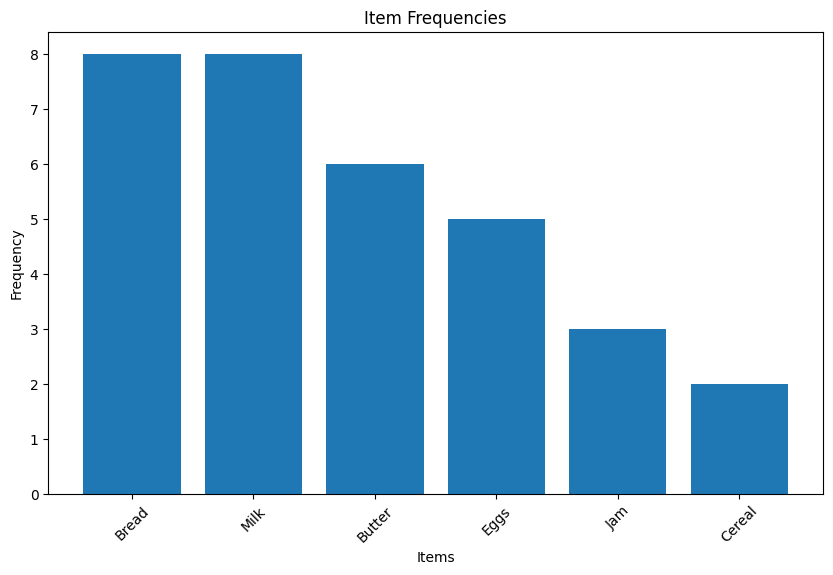

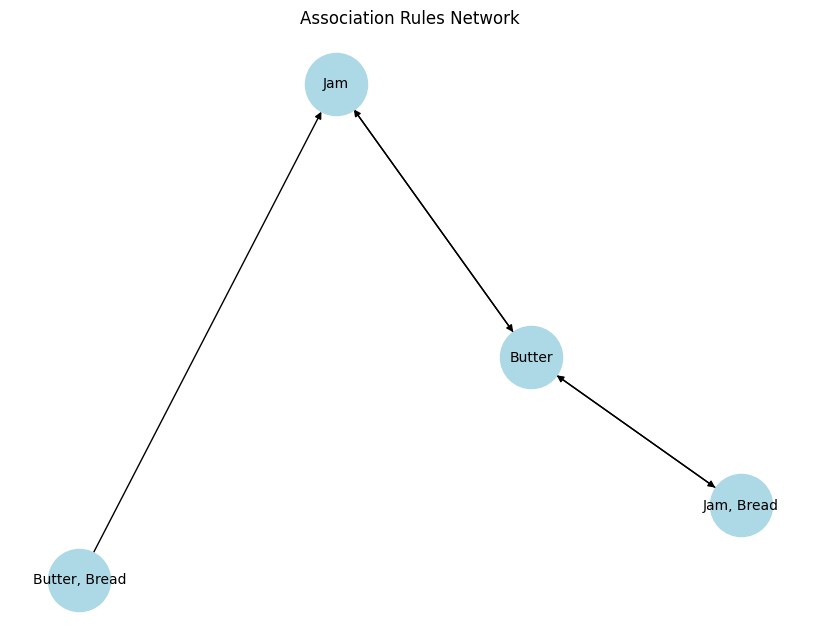


Business Interpretation
Strongest Rule: Butter -> Jam
Lift: 1.6666666666666667

Marketing Suggestions
1. Place related products near each other
2. Offer combo discounts
3. Recommend related items to customers

Results saved to association_rules.csv


In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")


print("="*60)
print("MARKET BASKET ANALYSIS USING APRIORI")
print("="*60)

# Sample transaction data
transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]

print("Total transactions:", len(transactions))

# Convert transactions to binary matrix
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)
print("\nBinary Matrix:")
print(df.head())

# Basic statistics
item_freq = df.sum().sort_values(ascending=False)

print("\nItem Frequencies:")
print(item_freq)

trans_lengths = [len(t) for t in transactions]

print("\nAverage items per transaction:", np.mean(trans_lengths))
print("Min items:", min(trans_lengths))
print("Max items:", max(trans_lengths))

print("\n" + "="*60)
print("APRIORI RESULTS")
print("="*60)

# Generate frequent itemsets
min_support = 0.3
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("\nAssociation Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']])

# Filter rules by confidence
rules = rules[rules['confidence'] >= 0.5]

print("\nFiltered Rules (confidence >= 0.5):")
print(rules[['antecedents','consequents','support','confidence','lift']])

print("\n" + "="*60)
print("TOP RULES")
print("="*60)

# Top rules by lift
top_lift = rules.nlargest(5, 'lift')

print("\nTop 5 Rules by Lift")

for i,(idx,row) in enumerate(top_lift.iterrows(),1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))

    print(f"{i}. {ante} -> {cons}")
    print(f"Support:{row['support']:.2f} Confidence:{row['confidence']:.2f} Lift:{row['lift']:.2f}")

# Visualization - Item frequency
plt.figure(figsize=(10,6))

plt.bar(item_freq.index, item_freq.values)

plt.title("Item Frequencies")
plt.xlabel("Items")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.show()

# Network Graph
if len(rules) > 0:

    G = nx.DiGraph()

    for idx,row in top_lift.iterrows():
        ante = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))

        G.add_edge(ante, cons, weight=row['lift'])

    plt.figure(figsize=(8,6))

    pos = nx.spring_layout(G)

    nx.draw(G,pos,
            with_labels=True,
            node_color='lightblue',
            node_size=2000,
            font_size=10,
            arrows=True)

    plt.title("Association Rules Network")
    plt.show()

# Business interpretation
print("\nBusiness Interpretation")

if len(rules) > 0:

    best_rule = rules.nlargest(1,'lift').iloc[0]

    ante = ', '.join(list(best_rule['antecedents']))
    cons = ', '.join(list(best_rule['consequents']))

    print("Strongest Rule:", ante, "->", cons)
    print("Lift:", best_rule['lift'])

print("\nMarketing Suggestions")
print("1. Place related products near each other")
print("2. Offer combo discounts")
print("3. Recommend related items to customers")

# Save results
rules[['antecedents','consequents','support','confidence','lift']].to_csv("association_rules.csv", index=False)

print("\nResults saved to association_rules.csv")